# the plan

3 types of clustering:

- heirarchical clustering
- k-means in UMAP/ISOMAP space
- MDL (naive + greedy)

then:

- 3d vis of these clusters
- stats on how the clusters match up

In [32]:
from pathlib import Path

import pandas as pd
import torch
import matplotlib.pyplot as plt

from spd.analysis.embedding import get_comp_dist_mat, plot_embedding_result, sweep_embedding_param
from spd.analysis.grouping import (
    CoactivationResults,
	CoactivationResultsGroup,
    get_coactivations,
    plot_clustering_from_results,
)
from spd.data_utils import SparseFeatureDataset
from spd.experiments.resid_mlp.resid_mlp_dataset import ResidualMLPDataset
from spd.utils import get_device
from spd.analysis.grouping import print_coac_info

from muutils.dbg import dbg_auto, dbg_tensor

DEVICE = get_device()
torch.set_grad_enabled(False)
print(f"Using device: {DEVICE = }")

Using device: DEVICE = 'cuda'


In [ ]:
# magic autoreload
%load_ext autoreload
%autoreload 2

# TMS + identity

In [33]:
coactivations_tms: CoactivationResultsGroup = get_coactivations(
    model_path=Path("../data/tms-decomp/model_40000.pth"),
    dataset_cls=SparseFeatureDataset,
    dataset_kwargs=dict(
        value_range=(0.0, 1.0),
        synced_inputs=None,
    ),
    coactivations_kwargs=dict(
        module_groups=[["linear1", "linear2"]],
    ),
    device=DEVICE,
)["group_0"]

In [34]:
dbg_auto(coactivations_tms);

/home/miv/projects/tools/muutils/muutils/tensor_info.py:238: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  hist, bins = np.histogram(A_hist, bins=hist_bins)
[ <ipykernel>:1 ] coactivations_tms: <dict of len()=12, key_types={str}, val_types={Tensor, dict, float, int, list, ndarray}>
  co_occurrence_matrix: μ=147.22 σ=1295.46 x̃=0.00 R=[0.00,201732.00] ℙ=|█      | shape=(400,400) dtype=torch.float32 device=cuda:0 ∇✗
  marginal_counts: μ=6344.21 σ=15714.57 x̃=0.00 R=[0.00,201732.00] ℙ=|█      | shape=400 dtype=torch.float32 device=cuda:0 ∇✗
  module_slices:   <dict of len()=2, key_types={str}, val_types={slice}>
    linear1: slice(0, 200, None)
    linear2: slice(200, 400, None)
  modules: ['linear1', 'linear2']
  labels: shape=400 dtype=<U7
  group_masks: μ=-0.14 σ=0.66 x̃=-0.00 R=[-7.93,1.00] ℙ=|      █| shape=(1000,400) dtype=torch.float32 device=cuda:0 ∇✗
  active_mask: μ=0.01 σ=0.11 x̃=0.00 R=[0.00,1.00] ℙ=|█      | shape=(1000,400) dtype=to

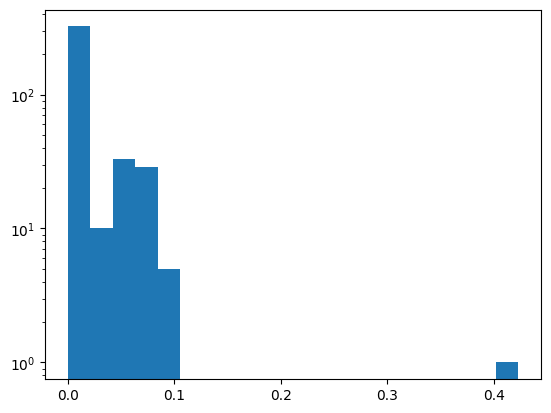

In [29]:
# plt.matshow(coactivations_tms["group_0"]["group_masks"].cpu())
# plt.show()
# plt.matshow(coactivations_tms["group_0"]["active_mask"].cpu())
# plt.show()
plt.hist(coactivations_tms["group_0"]["active_freq"].cpu(), bins=20);
plt.yscale("log")


/home/miv/projects/tools/muutils/muutils/tensor_info.py:238: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  hist, bins = np.histogram(A_hist, bins=hist_bins)
[ <ipykernel>:5 ] hclust_res: <dict of len()=7, key_types={str}, val_types={Figure, int, ndarray}>
  fig: <Figure size 1200x600 with 2 Axes>
  clusters: μ=24.02 σ=14.24 x̃=25.00 R=[1.00,45.00] ℙ=|▅▃▃▄▃▃█| shape=115 dtype=int32
  Z: μ=59.45 σ=72.15 x̃=16.00 R=[0.00,227.00] ℙ=|█▁▁▁▁▁▁| shape=(114,4) dtype=float64
  alive_mask: μ=0.29 σ=0.45 x̃=0.00 R=[0.00,1.00] ℙ=|█     ▃| shape=400 dtype=bool
  n_clusters: 45
  cluster_sizes: μ=2.56 σ=3.19 x̃=2.00 R=[1.00,22.00] ℙ=|█      | shape=45 dtype=int64
  n_active: 115


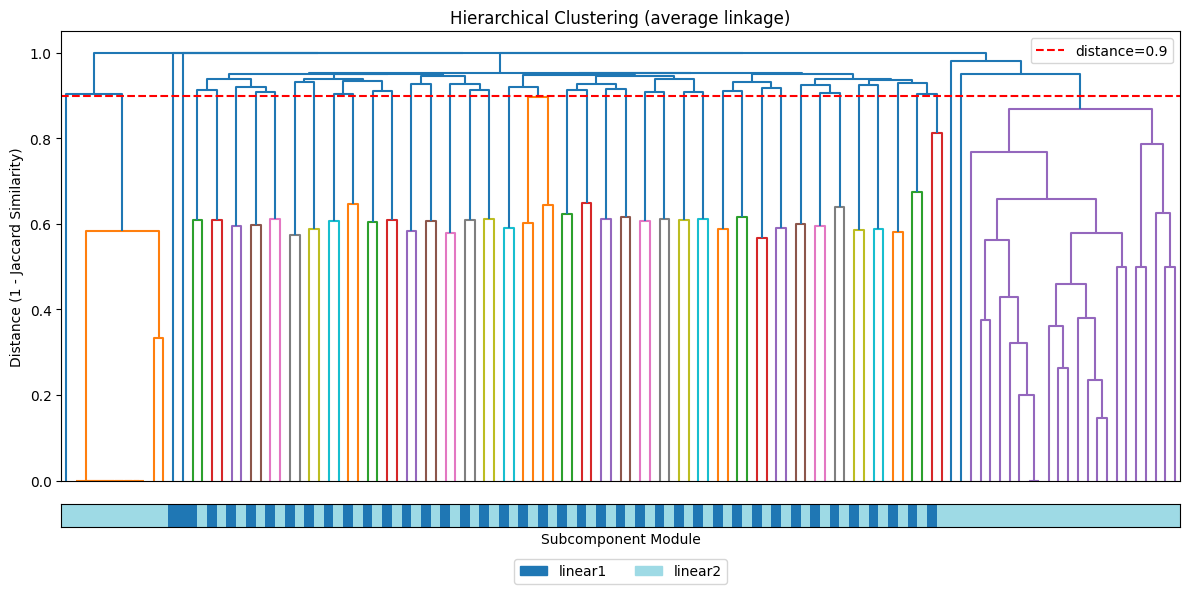

In [27]:
hclust_res = plot_clustering_from_results(
    results=coactivations_tms,
)

dbg_auto(hclust_res);

In [ ]:
def get_embedding_vis() -> str:
    import requests
    return requests.get(
        "https://raw.githubusercontent.com/mivanit/js-embedding-vis/refs/heads/main/bundled/index.html",
        timeout=10,
    ).text

get_embedding_vis()

In [ ]:

tms_dist = get_comp_dist_mat(coactivations_tms["group_0"])

for method in ["umap", "isomap"]:
    plot_embedding_result(
        sweep_embedding_param(
            dist=tms_dist,
            method=method,
            param_name="n_neighbors",
            param_values=[2, 3, 4, 8, 16, 32, 64, 128, 256],
            n_components=2,
        )
    )

# 1 layer residual MLP

In [ ]:
coactivations_mlp: CoactivationResults = get_coactivations(
    model_path=Path("../data/mlp-decomp/model_30000.pth"),
    dataset_cls=ResidualMLPDataset,
    dataset_kwargs=dict(
        calc_labels=False,  # Our labels will be the output of the target model
        label_type=None,
        act_fn_name=None,
        label_fn_seed=None,
        label_coeffs=None,
        synced_inputs=None,
    ),
    coactivations_kwargs=dict(
        module_groups=[["layers.0.mlp_in", "layers.0.mlp_out"]],
    ),
    device=DEVICE,
)
plot_clustering_from_results(
    results=coactivations_mlp,
    title="MLP Coactivations",
);

# 3 layer residual MLP

In [ ]:
coactivations_mlp3: CoactivationResults = get_coactivations(
    model_path=Path("../data/mlp3-decomp/model_120000.pth"),
    dataset_cls=ResidualMLPDataset,
    dataset_kwargs=dict(
        calc_labels=False,  # Our labels will be the output of the target model
        label_type=None,
        act_fn_name=None,
        label_fn_seed=None,
        label_coeffs=None,
        synced_inputs=None,
    ),
    coactivations_kwargs=dict(
        module_groups=[
            [
                "layers.0.mlp_in",
                "layers.0.mlp_out",
                "layers.1.mlp_in",
                "layers.1.mlp_out",
                "layers.2.mlp_in",
                "layers.2.mlp_out",
            ]
        ],
    ),
    device=DEVICE,
)

_, mlp3_clusters, _, mlp3_alive_mask = plot_clustering_from_results(
    coactivations_mlp3,
    group_key="group_0",
    linkage_method="average",
    threshold=0.8,
    # linkage_method="complete",
    # threshold=0.85,
    title="3-layer Residual MLP Hierarchical Clustering",
    min_alive_counts=500,
    figsize=(15, 6),
)

In [ ]:
submodules = coactivations_mlp3["group_0"]["labels"][mlp3_alive_mask]
# Get top 10 clusters by size
cluster_sizes = pd.Series(mlp3_clusters).value_counts()

for cluster_id in cluster_sizes.index[0::10]:
    cluster_mask = mlp3_clusters == cluster_id
    submodule_counts = pd.Series(submodules[cluster_mask]).value_counts()

    print(f"\nCluster {cluster_id} ({cluster_sizes[cluster_id]} elements):")
    for submodule, count in submodule_counts.items():
        print(f"  {submodule}: {count}")